In [9]:
import geopandas as gpd
rel_path = '/data01/FDS/muduchuru/Data/Agri/EnSv8/data/'
gds = gpd.read_file(rel_path + 'ens_v8.shp')

In [10]:
gds#.plot(column='EnZ')

,EnS,EnS_name,EnZ,EnZ_name,Area_km2,geometry
0,1,ALN1,1,ALN,135213.0,"MULTIPOLYGON (((4579000 4712000, 4578000 47120..."
1,2,BOR1,2,BOR,147149.0,"MULTIPOLYGON (((4678000 4795000, 4678000 47930..."
2,3,ALN2,1,ALN,107998.0,"MULTIPOLYGON (((4196000 4076000, 4197000 40760..."
3,4,BOR2,2,BOR,111965.0,"MULTIPOLYGON (((4256000 4073000, 4257000 40730..."
4,5,BOR3,2,BOR,116692.0,"MULTIPOLYGON (((4974000 4599000, 4973000 45990..."
...,...,...,...,...,...,...
79,80,MDM11,11,MDM,108374.0,"MULTIPOLYGON (((3953000 1338000, 3953000 13370..."
80,81,MDS6,13,MDS,65003.0,"MULTIPOLYGON (((2921000 1452000, 2920000 14520..."
81,82,MDS7,13,MDS,56291.0,"MULTIPOLYGON (((5618000 1429000, 5618000 14300..."
82,83,MDS8,13,MDS,97398.0,"MULTIPOLYGON (((4439000 1311000, 4439000 13070..."


In [15]:
import pandas as pd 
rel_path = '/data01/FDS/muduchuru/Data/Agri/Phenology'
ds_phen = pd.read_csv(rel_path + '/EU_Phenology_Complete_ver2019_01_32278_359040133.csv', sep=';')
gds_grid = gpd.read_file(rel_path + '/grid_25km.shp')

In [30]:
merged_gdf = gds_grid.merge(
    ds_phen,
    left_on="Grid_Code",  # Column name in gds_grid
    right_on="IDGRID",  # Column name in ds_phen
    how="outer",  # Use 'left' to keep all grid cells, even without phenology data
)

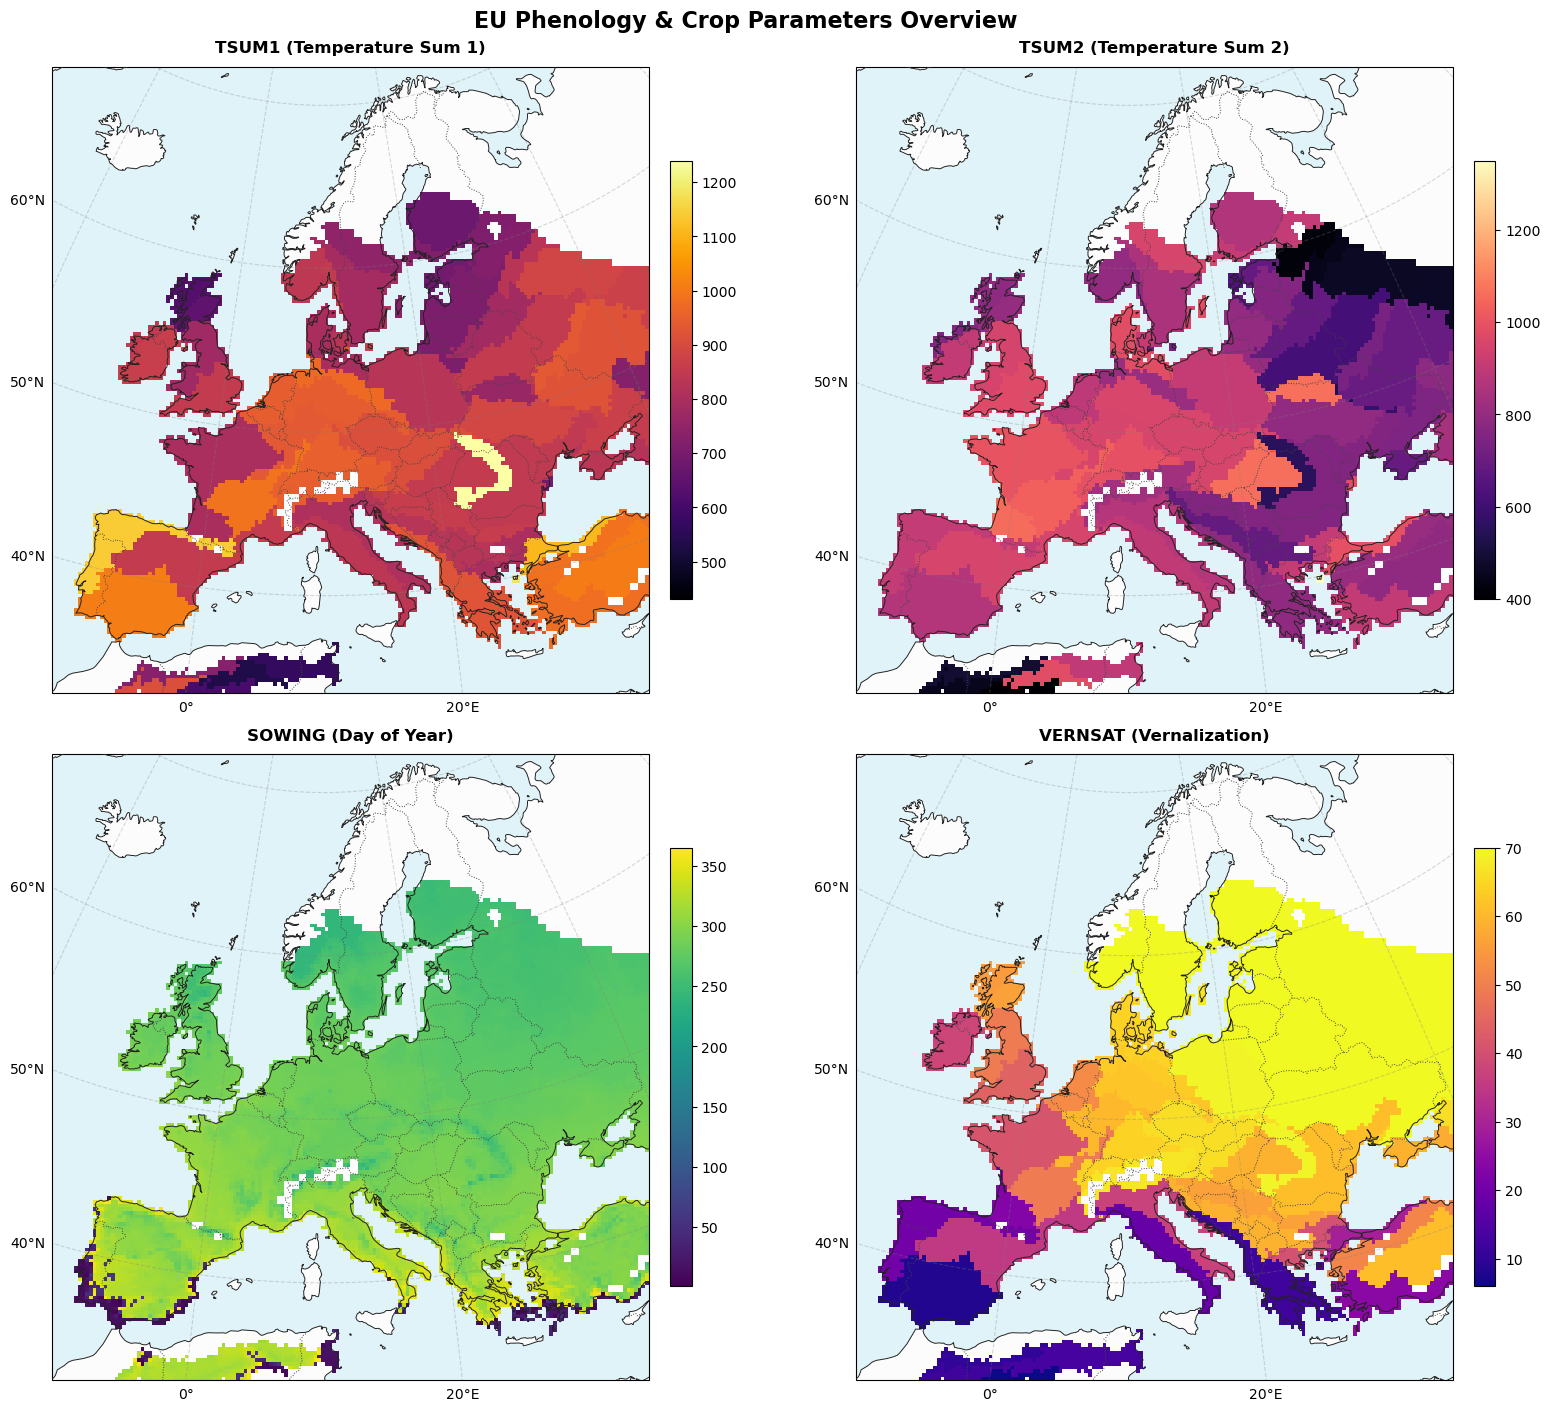

In [39]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 1. Set up the 2x2 grid with EPSG:3035 projection
eu_crs = ccrs.epsg(3035)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14),
    subplot_kw={"projection": eu_crs},
    constrained_layout=True,
)

# 2. Define variables and plot settings
variables = [
    {"col": "TSUM1", "title": "TSUM1 (Temperature Sum 1)", "cmap": "inferno"},
    {"col": "TSUM2", "title": "TSUM2 (Temperature Sum 2)", "cmap": "magma"},
    {"col": "SOWING", "title": "SOWING (Day of Year)", "cmap": "viridis"},
    {"col": "VERNSAT", "title": "VERNSAT (Vernalization)", "cmap": "plasma"},
]

# Flatten axes array for straightforward iteration
axes_flat = axes.flatten()

# 3. Loop through variables and create subplots
for ax, var in zip(axes_flat, variables):
    # Add background features
    ax.add_feature(cfeature.OCEAN, facecolor="#e0f3f8", zorder=1)
    ax.add_feature(cfeature.LAND, facecolor="#fcfcfc", zorder=1)

    # Plot spatial data grid
    merged_gdf.plot(
        column=var["col"],
        cmap=var["cmap"],
        ax=ax,
        legend=True,
        zorder=2,
        legend_kwds={"orientation": "vertical", "shrink": 0.7, "pad": 0.03},
    )

    # Overlay country borders and coastlines on top of data
    ax.add_feature(
        cfeature.COASTLINE, linewidth=0.7, edgecolor="#222222", zorder=3
    )
    ax.add_feature(
        cfeature.BORDERS,
        linestyle=":",
        linewidth=0.7,
        edgecolor="#444444",
        zorder=3,
    )

    # Focus map extent on Europe
    ax.set_extent([-10, 34, 34, 71], crs=ccrs.PlateCarree())

    # Format gridlines
    gl = ax.gridlines(
        draw_labels=True, linestyle="--", alpha=0.3, color="gray", zorder=4
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(var["title"], fontsize=12, fontweight="bold", pad=10)

plt.suptitle(
    "EU Phenology & Crop Parameters Overview", fontsize=16, fontweight="bold"
)
plt.show()

In [38]:
ds_phen

,IDGRID,TSUM1,TSUM2,SOWING,VERNSAT
0,11024,611,400,13,6
1,12017,611,400,13,6
2,12024,611,400,13,6
3,12029,611,400,18,6
4,12030,611,400,17,6
...,...,...,...,...,...
14170,162139,677,862,248,70
14171,162140,677,862,250,70
14172,162141,677,862,249,70
14173,162142,677,862,252,70
